In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")

# ── Verificar GPU ─────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ Usando GPU: {gpus[0].name}")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("⚠️  GPU no encontrada, usando CPU")

2026-06-03 10:30:35.669559: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-03 10:30:35.678374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780482635.687679    2136 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780482635.690706    2136 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-03 10:30:35.702224: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

TensorFlow version: 2.18.1
✅ Usando GPU: /physical_device:GPU:0


In [ ]:
TRAIN_DIR   = '/workspace/dataset/train/'
TEST_DIR    = '/workspace/dataset/test/'

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 1e-3
DROPOUT     = 0.2
PATIENCE    = 5
VAL_SPLIT   = 0.2
SEED        = 123
AUTOTUNE    = tf.data.AUTOTUNE

# Subconjunto para pruebas rápidas (poner None para usar el dataset completo)
TRAIN_SAMPLES = None
TEST_SAMPLES  = None

In [ ]:
train_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='training'
)


val_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='validation'
)

test_ds_full = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED
)

class_names = train_ds_full.class_names
print(f"Clases detectadas: {class_names}")

# Subconjunto para pruebas rápidas
if TRAIN_SAMPLES:
    train_ds = train_ds_full.take(TRAIN_SAMPLES // BATCH_SIZE + 1)
    val_ds   = val_ds_full.take((TRAIN_SAMPLES // 4) // BATCH_SIZE + 1)
else:
    train_ds = train_ds_full
    val_ds   = val_ds_full

if TEST_SAMPLES:
    test_ds = test_ds_full.take(TEST_SAMPLES // BATCH_SIZE + 1)
else:
    test_ds = test_ds_full

print(f"Batches — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

Found 47874 files belonging to 2 classes.
Using 38300 files for training.


I0000 00:00:1780482637.141339    2136 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20712 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 47874 files belonging to 2 classes.
Using 9574 files for validation.
Found 11965 files belonging to 2 classes.
Clases detectadas: ['fake', 'real']
Batches — train: 1197, val: 300, test: 374


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def resize_only(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

def resize_and_augment(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = data_augmentation(image, training=True)
    return image, label

train_ds = (
    train_ds
    .map(resize_and_augment, num_parallel_calls=AUTOTUNE)
    #.cache()
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(resize_only, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(resize_only, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

image_batch, labels_batch = next(iter(train_ds))
print(f"Rango de píxeles → min: {np.min(image_batch):.1f}, max: {np.max(image_batch):.1f}")
print(f"Shape del batch: {image_batch.shape}")
print(f"Etiquetas del batch: {labels_batch.numpy()[:8]}")

Rango de píxeles → min: 0.0, max: 255.0
Shape del batch: (32, 224, 224, 3)
Etiquetas del batch: [0 0 1 0 1 1 0 1]


In [ ]:
def build_model(img_size: int = IMG_SIZE, dropout_rate: float = DROPOUT,
                learning_rate: float = LR) -> keras.Model:
    """
    EfficientNetB0 con cabeza de clasificación binaria.
    backbone.trainable = False solo se entrena la cabeza.
    """
    inputs = layers.Input(shape=(img_size, img_size, 3))

    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False   # congelar backbone

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate, name="top_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="pred")(x)

    model = keras.Model(inputs, outputs, name="EfficientNet")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model


model = build_model()
model.summary()

trainable_params = sum(
    np.prod(v.shape) for v in model.trainable_weights
)
total_params = sum(
    np.prod(v.shape) for v in model.weights
)
print(f"\nParámetros entrenables: {trainable_params:,} / {total_params:,} "
      f"({100 * trainable_params / total_params:.1f}%)")

Model: "EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,972 (15.47 MB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)


Parámetros entrenables: 3,841 / 4,055,972.0 (0.1%)


In [ ]:
callbacks = [
    # Guarda el mejor modelo según val_auc
    keras.callbacks.ModelCheckpoint(
        "best_model_cnn_salida.keras",
        monitor="val_auc",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

hist = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/100


I0000 00:00:1780482644.270494    2315 service.cc:148] XLA service 0x7f3e081135a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780482644.270524    2315 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-06-03 10:30:48.260384: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780482652.186414    2315 cuda_dnn.cc:529] Loaded cuDNN version 91002
E0000 00:00:1780482654.838403    2315 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780482654.917799    2315 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780482655.105061    2315

 109/1197 ━━━━━━━━━━━━━━━━━━━━ 2:01 111ms/step - accuracy: 0.6400 - auc: 0.6934 - loss: 0.7258

2026-06-03 10:31:10.446513: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


 129/1197 ━━━━━━━━━━━━━━━━━━━━ 2:05 117ms/step - accuracy: 0.6491 - auc: 0.7046 - loss: 0.7105

...

1101/1197 ━━━━━━━━━━━━━━━━━━━━ 17s 187ms/step - accuracy: 0.8351 - auc: 0.9169 - loss: 0.3664

Corrupt JPEG data: premature end of data segment


1142/1197 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - accuracy: 0.8352 - auc: 0.9169 - loss: 0.3664

2026-06-03 12:20:14.844829: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


1197/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.8352 - auc: 0.9169 - loss: 0.3665
Epoch 29: val_auc did not improve from 0.93710
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 224s 187ms/step - accuracy: 0.8362 - auc: 0.9167 - loss: 0.3668 - val_accuracy: 0.8658 - val_auc: 0.9368 - val_loss: 0.3253 - learning_rate: 1.5625e-05
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 24.


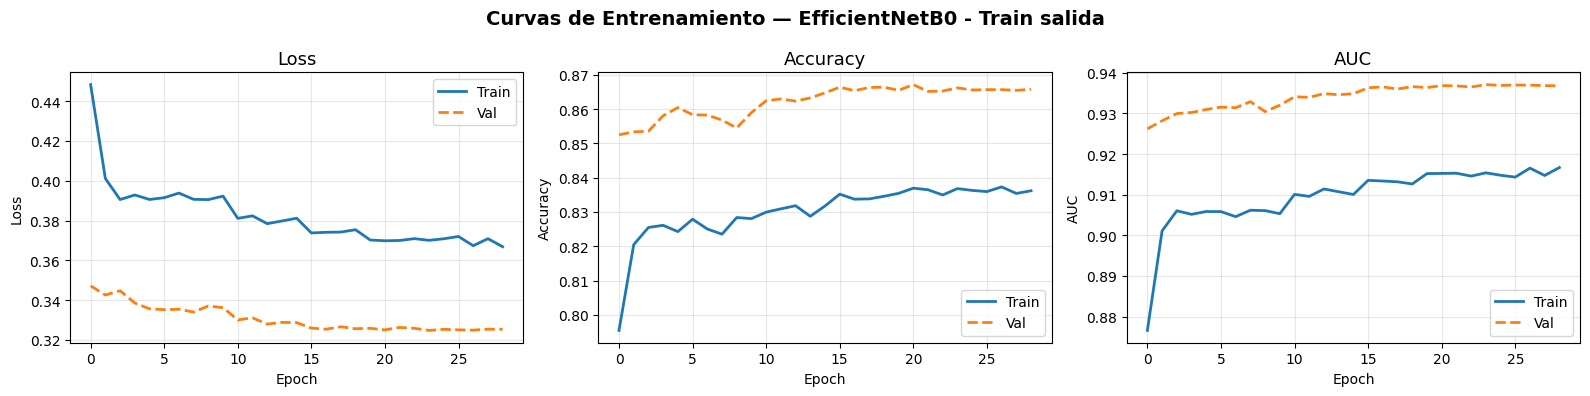

In [7]:
def plot_history(hist):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics = [
        ('loss',     'Loss',     'Loss'),
        ('accuracy', 'Accuracy', 'Accuracy'),
        ('auc',      'AUC',      'AUC'),
    ]
    for ax, (key, title, ylabel) in zip(axes, metrics):
        ax.plot(hist.history[key],     label='Train', linewidth=2)
        ax.plot(hist.history[f'val_{key}'], label='Val', linewidth=2, linestyle='--')
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle('Curvas de Entrenamiento — EfficientNetB0 - Train salida', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/workspace/imagenes_metricas_full_dataset/training_curves_cnn_salida_final.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(hist)

In [8]:
print("=" * 45)
print("EVALUACIÓN FINAL SOBRE TEST SET")
print("=" * 45)
test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=1)
print(f"\nLoss:     {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"AUC:      {test_auc:.4f}")

EVALUACIÓN FINAL SOBRE TEST SET
 15/374 ━━━━━━━━━━━━━━━━━━━━ 1:06 184ms/step - accuracy: 0.8774 - auc: 0.9503 - loss: 0.3016

2026-06-03 12:20:27.850306: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


142/374 ━━━━━━━━━━━━━━━━━━━━ 38s 165ms/step - accuracy: 0.8599 - auc: 0.9372 - loss: 0.3249

Corrupt JPEG data: premature end of data segment


337/374 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.8587 - auc: 0.9362 - loss: 0.3273

2026-06-03 12:21:20.967559: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


370/374 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.8587 - auc: 0.9361 - loss: 0.3275

E0000 00:00:1780489287.678471    2318 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780489287.758400    2318 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780489287.947150    2318 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780489288.028604    2318 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780489288.389159    2318 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

374/374 ━━━━━━━━━━━━━━━━━━━━ 65s 174ms/step - accuracy: 0.8578 - auc: 0.9349 - loss: 0.3299

Loss:     0.3299
Accuracy: 0.8578  (85.78%)
AUC:      0.9349


In [ ]:
y_true_list = []
y_pred_list = []
y_prob_list = []

for x_batch, y_batch in test_ds:
    y_true_list.extend(y_batch.numpy())

    probs = model.predict_on_batch(x_batch)
    y_prob_list.extend(probs.flatten())
    y_pred_list.extend((probs > 0.5).astype(int).flatten())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_prob = np.array(y_prob_list)

print("Distribución y_true:", np.bincount(y_true))
print("Distribución y_pred:", np.bincount(y_pred))

Distribución y_true: [5970 5995]
Distribución y_pred: [6053 5912]


2026-06-03 12:21:38.216743: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


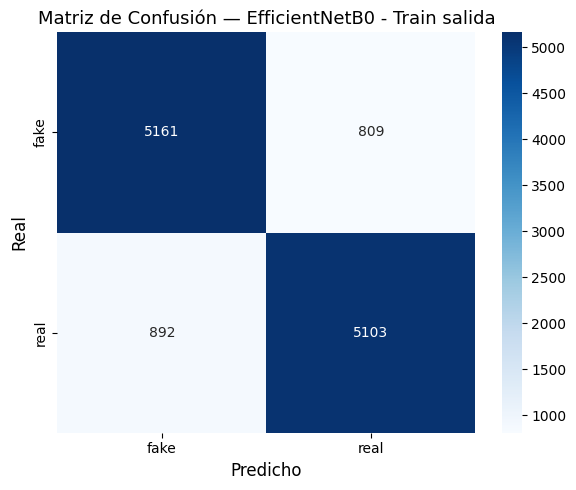


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fake       0.85      0.86      0.86      5970
        real       0.86      0.85      0.86      5995

    accuracy                           0.86     11965
   macro avg       0.86      0.86      0.86     11965
weighted avg       0.86      0.86      0.86     11965



In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión — EfficientNetB0 - Train salida', fontsize=13)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/confusion_matrix_cnn_salida_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

Imagen guardada como classification_report.png


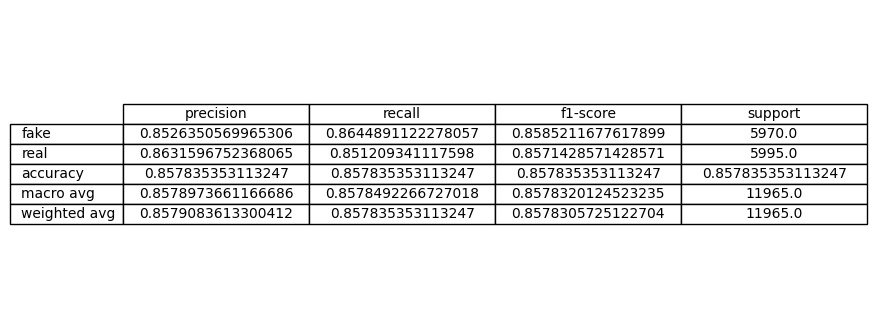

In [ ]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=df_report.values, 
                 colLabels=df_report.columns, 
                 rowLabels=df_report.index, 
                 cellLoc='center', 
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.savefig('/workspace/imagenes_metricas_full_dataset/classification_report_cnn_salida_final.png', bbox_inches='tight', dpi=300)
print("Imagen guardada como classification_report.png")

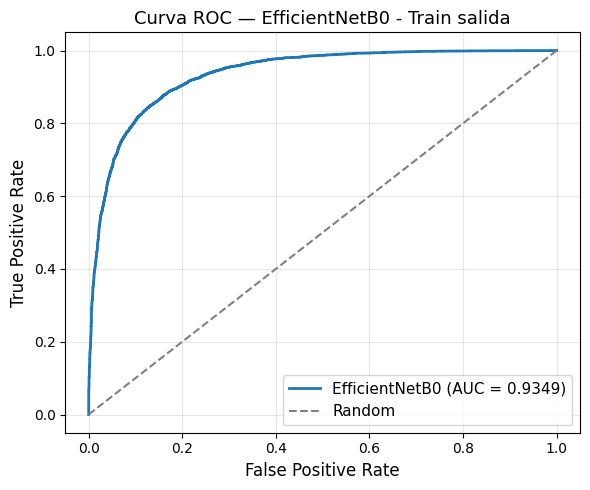

AUC final (test completo): 0.9349


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_score   = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'EfficientNetB0 (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC — EfficientNetB0 - Train salida', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/roc_curve_cnn_salida_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC final (test completo): {auc_score:.4f}")